# AIoT Project

This notebook is the entry point for the analysis pipeline. It assumes the PAMAP2 dataset has already been parsed and ingested into MongoDB by `aiot_dataset_creation_sample.ipynb` — every cell below should fetch its inputs from the MongoDB collection, **not** from the raw `.dat` files.

In [4]:
import os
from collections import defaultdict

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# sklearn for scaling
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

# sklearn for classification models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# sklearn for model evaluation(metrics)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# sklearn for model optimization(GridSearch)
from sklearn.model_selection import GridSearchCV

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

## Load configuration

In [5]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [6]:
client = pymongo.MongoClient(config["client"])

In [7]:
db = client[config["db"]]
coll = db[config["col"]]

In [8]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['Nordic walking', 'ascending stairs', 'car driving', 'computer work', 'cycling', 'descending stairs', 'folding laundry', 'house cleaning', 'ironing', 'lying', 'playing soccer', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking', 'watching TV']


## Load data

Fetch the documents that correspond to the **sensor configuration you are evaluating**. Start with the hand/wrist IMU in the AccGyr configuration (the default), e.g.:

```python
query = {"imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))
```

Carry the `subject` field through every transformation (windowing, filtering, feature extraction) — you will need it for the **subject-disjoint** train/test split below.

When you later expand to chest/ankle IMUs, change the query and re-run the pipeline so you can compare the per-configuration results in your report.

In [9]:
query = {"imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))
print(f"Number of documents fetched: {len(documents)}")

Number of documents fetched: 108


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

C:\Users\konst\AppData\Local\Temp\ipykernel_17680\4267574315.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


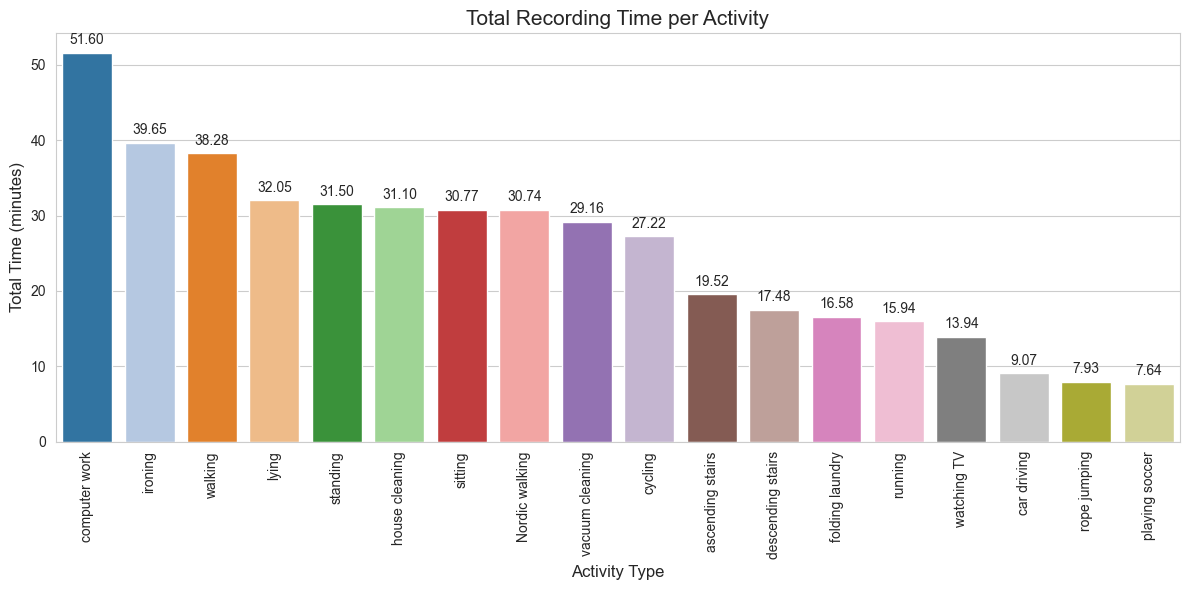

In [22]:
df = pd.DataFrame(documents)

# # Calculating segment duration in minutes for each row
df['segment_minutes'] = df.apply(
    lambda row: (len(row['data']['acc_x']) / row['sr']) / 60, axis=1
)

# Grouping by activity_label and summing segment_minutes
activity_totals = df.groupby('activity_label')['segment_minutes'].sum().reset_index()
activity_totals = activity_totals.sort_values(by='segment_minutes', ascending=False)

# Bar Plot Creation
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

barplot = sns.barplot(
    x='activity_label', 
    y='segment_minutes', 
    data=activity_totals, 
    palette='tab20'
)

plt.title('Total Recording Time per Activity', fontsize=15)
plt.xlabel('Activity Type', fontsize=12)
plt.ylabel('Total Time (minutes)', fontsize=12)
plt.xticks(rotation=90)

# Adding values above the bars
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'center', 
                        xytext = (0, 9), 
                        textcoords = 'offset points')

plt.tight_layout()
plt.show()

C:\Users\konst\AppData\Local\Temp\ipykernel_17680\2148024668.py:42: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


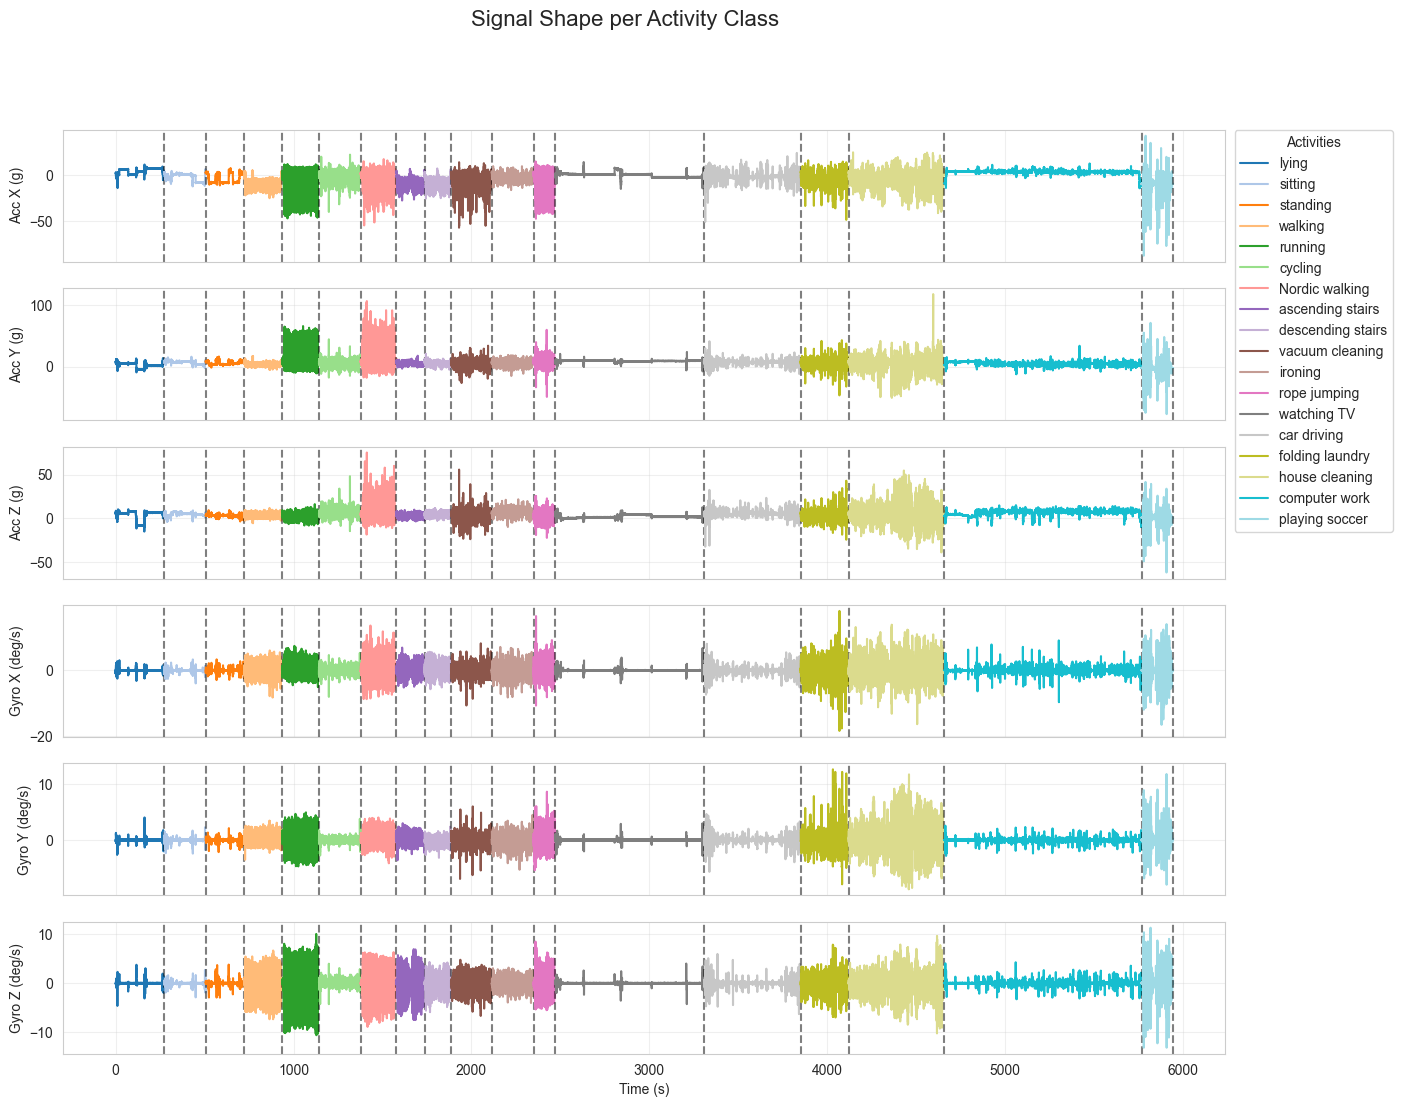

In [23]:
# Selecting one representative segment per activity
unique_activities = pd.DataFrame(documents)['activity_label'].unique()
selected_segments = []

for activity in unique_activities:
    segment = next(doc for doc in documents if doc['activity_label'] == activity)
    selected_segments.append(segment)

# Axes preparation (6 subplots)
fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True)
axes_labels = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
titles = ['Acc X (g)', 'Acc Y (g)', 'Acc Z (g)', 'Gyro X (deg/s)', 'Gyro Y (deg/s)', 'Gyro Z (deg/s)']

current_time = 0
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_activities))) 

# Plotting the data
for i, segment in enumerate(selected_segments):
    label = segment['activity_label']
    sr = segment['sr']
    data_len = len(segment['data']['acc_x'])
    
    time_axis = np.arange(data_len) / sr + current_time
    
    for j, axis_key in enumerate(axes_labels):
        signal = segment['data'][axis_key]
        
        axes[j].plot(time_axis, signal, color=colors[i], label=label if j == 0 else "")
        axes[j].set_ylabel(titles[j])
        axes[j].grid(True, alpha=0.3)

    for ax in axes:
        ax.axvline(x=time_axis[-1], color='black', linestyle='--', alpha=0.5)
        
    current_time = time_axis[-1]

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Signal Shape per Activity Class', fontsize=16)

axes[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1.05), title="Activities")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

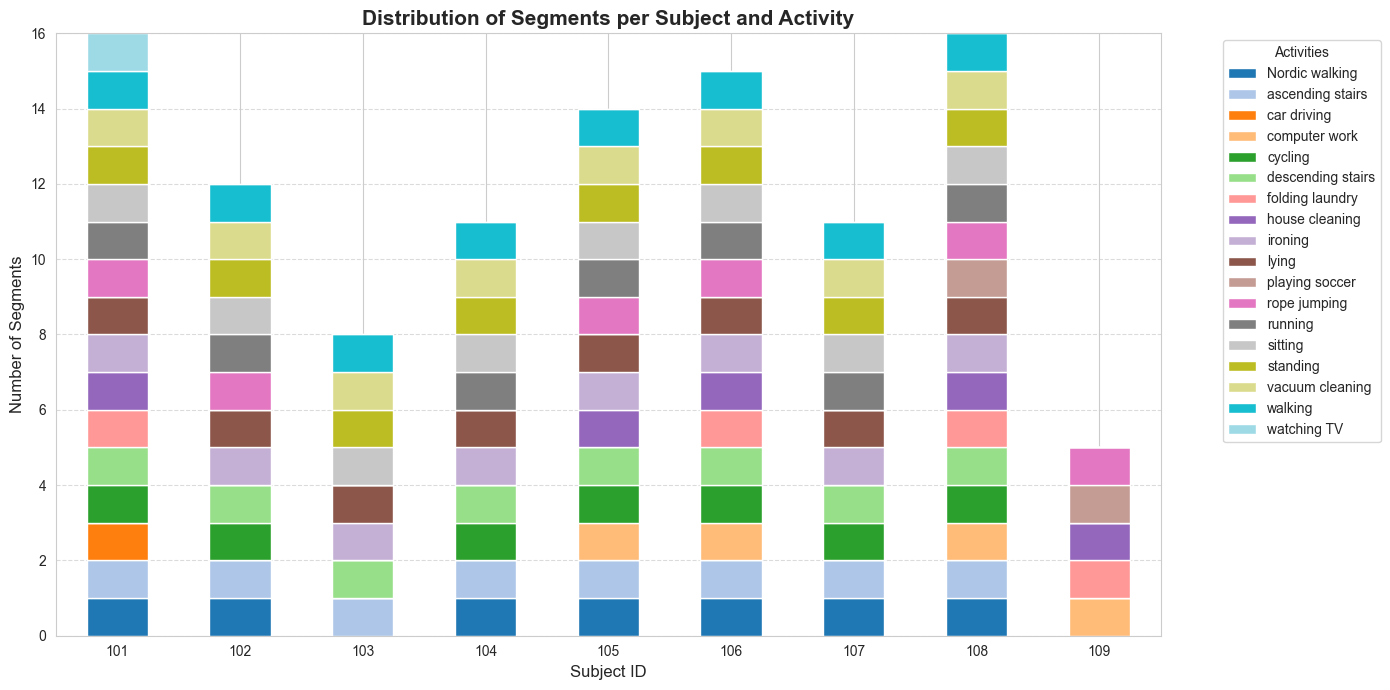

In [15]:
df = pd.DataFrame(documents)

# Calculating segment count per (subject, activity_label)
counts_df = df.groupby(['subject', 'activity_label']).size().reset_index(name='segment_count')

# Pivoting the DataFrame to have subjects as index and activity_labels as columns
pivot_df = counts_df.pivot(index='subject', columns='activity_label', values='segment_count').fillna(0)

# Stacked Bar Plot Creation
pivot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20', edgecolor='white')

plt.title('Distribution of Segments per Subject and Activity', fontsize=15, fontweight='bold')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Activities', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Data Processing

* Apply the sliding window algorithm to each segment (use `sliding_window_pd` from `utils.py` with the parameters defined in `config.yml`).
* Apply a low-pass Butterworth filter to each window (use `apply_filter` / `filter_instances` from `utils.py`).
* Detect outliers and confirm that no `NaN` values survive from the ingestion step.

Keep `(window, activity_label, subject)` triplets together throughout this section — you need the subject ID for the train/test split.

In [ ]:
# windows contains the sliding windows for all segments
# metadata contains the corresponding subject and activity_label for each window
windows = []
metadata = []

for doc in documents:
    segment_df = pd.DataFrame(doc['data'])
    
    # Sliding window application for the current segment using parameters from config
    segment_windows = sliding_window_pd(
        df=segment_df,
        ws=config['sliding_window']['ws'],
        overlap=config['sliding_window']['overlap'],
        w_type=config['sliding_window']['w_type'],
        w_center=config['sliding_window']['w_center'],
        print_stats=config['sliding_window']['print_stats']
    )

    # Adding the windows to the overall list
    windows.extend(segment_windows)

    # Metadata creation for each window of the segment
    for _ in range(len(segment_windows)):
        metadata.append({
            'subject': doc['subject'],
            'activity_label': doc['activity_label']
        })


In [ ]:
# Applying the specified filter to the windows using utils.py function
filtered_windows = filter_instances(
    instances_list=windows,
    order=config['filter']['order'],
    wn=config['filter']['wn'],
    filter_type=config['filter']['type']
)

Number of filtered instances in the list: 3445


          acc_x     acc_y     acc_z    gyr_x     gyr_y     gyr_z
12000 -53.78580  32.30200 -17.46260 -2.20574  3.500070  7.420970
12001 -48.57980  26.23770 -16.40200 -2.42294  3.835540  7.322840
12002 -45.97130  20.22430 -16.18870 -2.89837  4.313140  7.266870
12003 -42.64180  14.57490 -17.04340 -3.57605  4.855500  6.992260
12004 -39.26390   8.40756 -16.39470 -3.95618  5.180390  6.677750
...         ...       ...       ...      ...       ...       ...
13495  -1.42682   4.33432  -1.68935  2.64881 -1.277390  0.667088
13496  -1.60428   5.02036  -1.50188  2.37677 -0.985214  0.670460
13497  -1.85999   5.70632  -1.39256  1.86195 -0.599277  0.651127
13498  -2.07498   6.43059  -1.20579  1.13580 -0.156214  0.564866
13499  -2.48078   6.89075  -1.02099  0.32442  0.249365  0.447871

[1500 rows x 6 columns]
{'subject': '109', 'activity_label': 'playing soccer'}


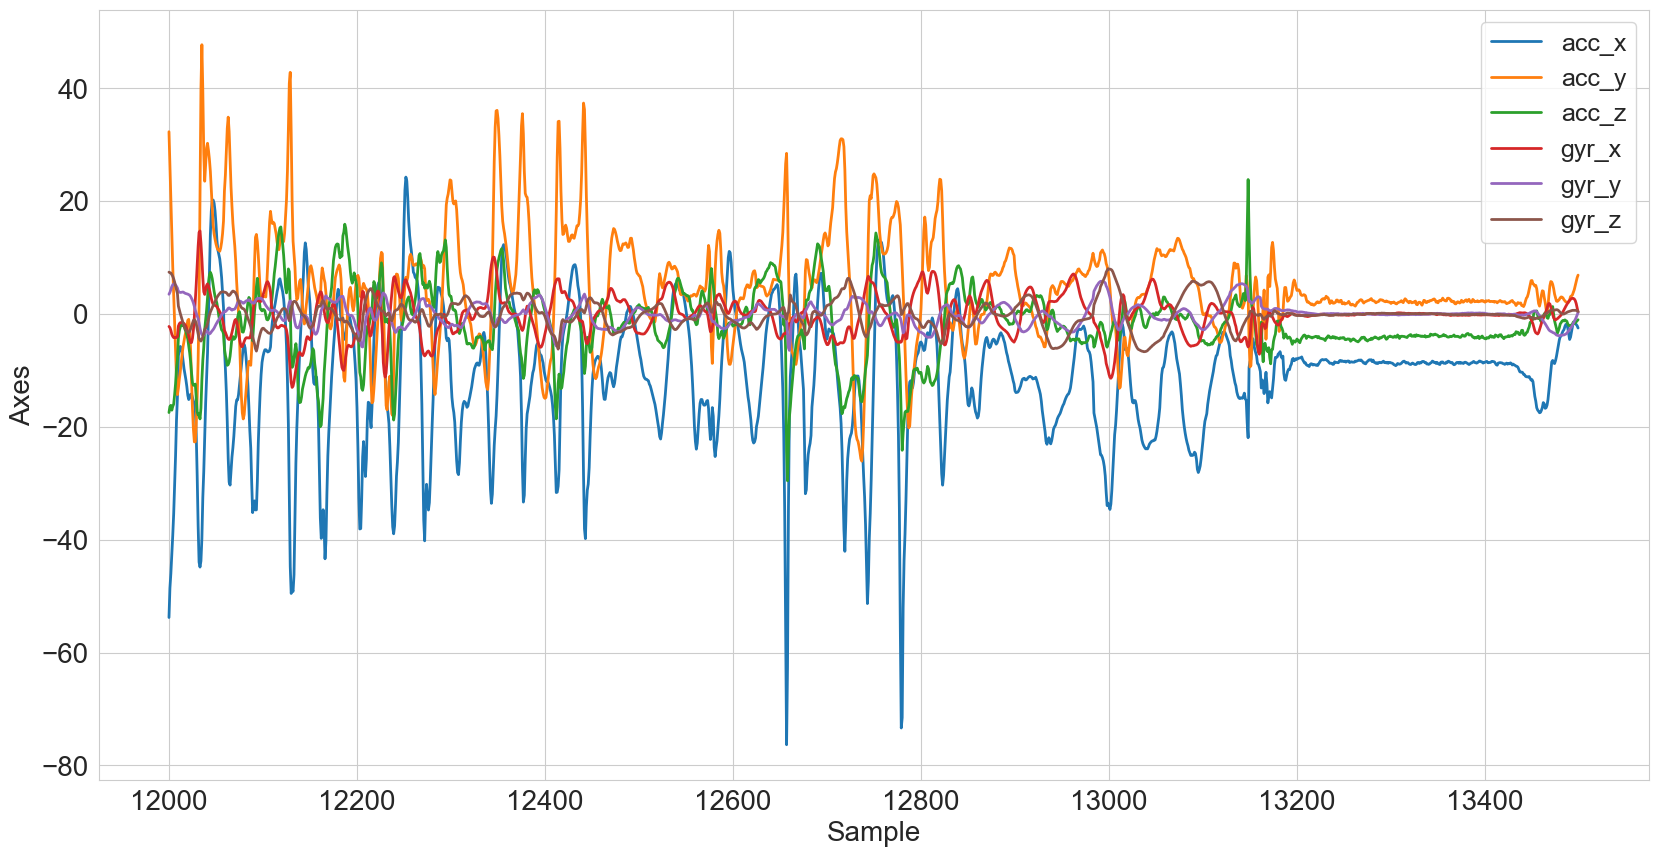

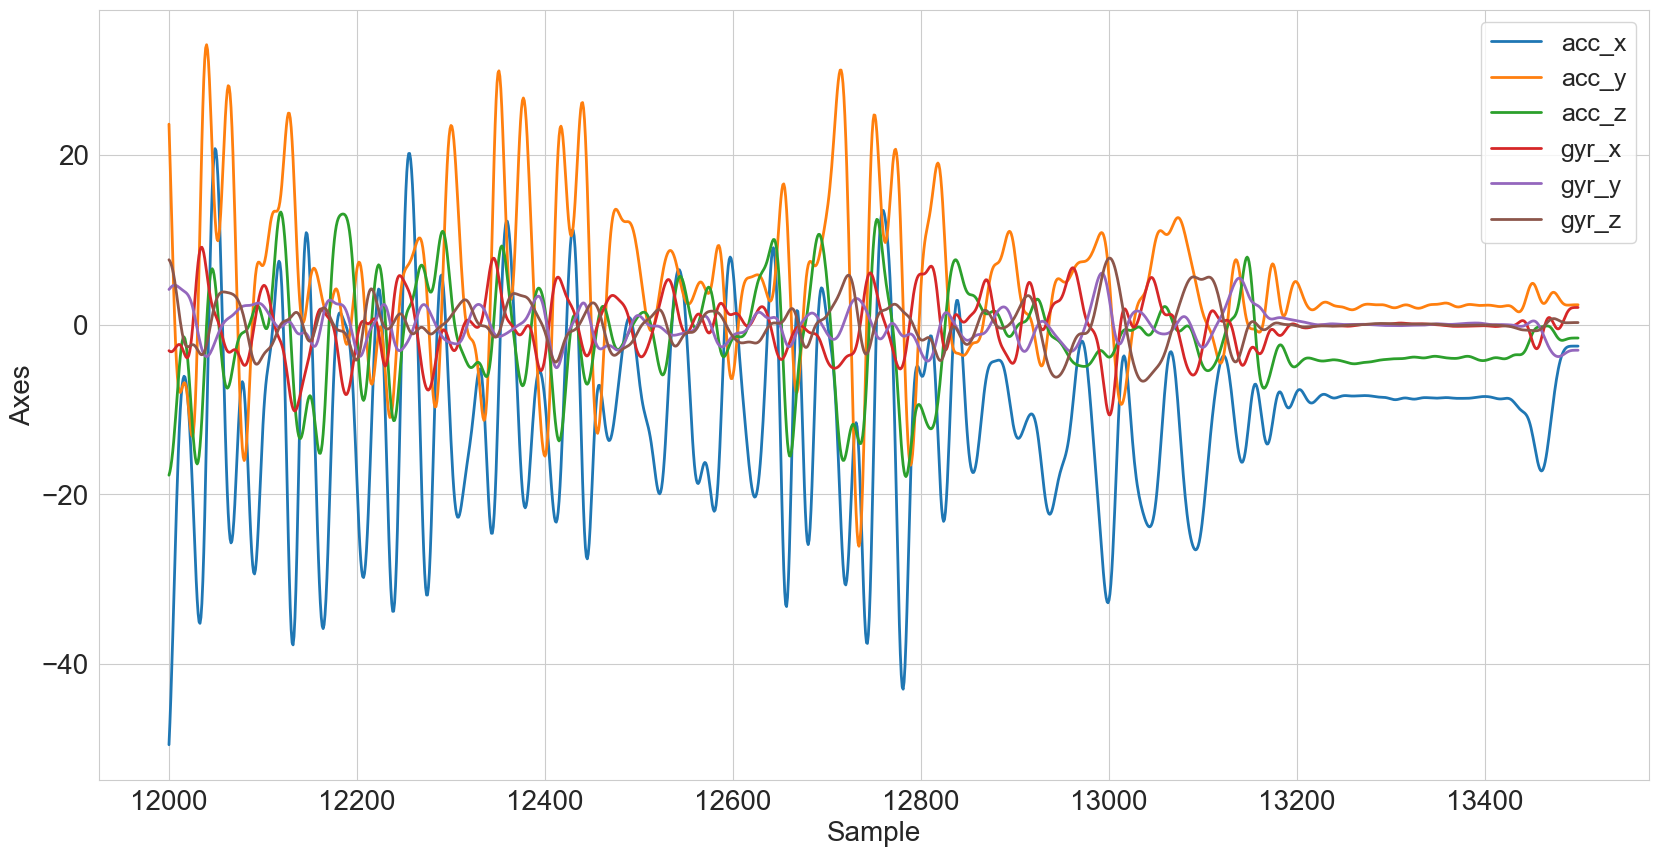

In [ ]:
# Visualizing one original and one filtered window to verify the filtering process
plot_instance_time_domain(windows[3000])
plot_instance_time_domain(filtered_windows[3000])

print(windows[3000])
print(metadata[3000])

# Feature Engineering


In [ ]:
# Feature extraction for each window
feature_list = []

for window in filtered_windows:
    row = {}
    for col in window.columns:
        signal = window[col].values
        row[f'{col}_mean'] = np.mean(signal)
        row[f'{col}_std'] = np.std(signal)
        row[f'{col}_min'] = np.min(signal)
        row[f'{col}_max'] = np.max(signal)
        row[f'{col}_range'] = np.max(signal) - np.min(signal)
        row[f'{col}_median'] = np.median(signal)
        row[f'{col}_iqr'] = np.percentile(signal, 75) - np.percentile(signal, 25)
        row[f'{col}_rms'] = np.sqrt(np.mean(signal**2))
        row[f'{col}_energy'] = np.sum(signal**2) / len(signal)
        row[f'{col}_skew'] = pd.Series(signal).skew()
        row[f'{col}_kurt'] = pd.Series(signal).kurt()
        row[f'{col}_zc'] = np.sum(np.diff(np.sign(signal)) != 0)
        row[f'{col}_mad'] = np.mean(np.abs(signal - np.mean(signal)))
        row[f'{col}_sma'] = np.sum(np.abs(signal)) / len(signal)

        fft_vals = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(len(signal), d=1/100)
        row[f'{col}_fft_mean_frequency'] = np.mean(fft_vals)
        row[f'{col}_fft_std'] = np.std(fft_vals)
        row[f'{col}_fft_spectral_energy'] = np.sum(fft_vals**2)
        row[f'{col}_dominant_freq'] = freqs[np.argmax(fft_vals)]
        row[f'{col}_spectral_entropy'] = scipy.stats.entropy(fft_vals / np.sum(fft_vals))
    feature_list.append(row)

X = pd.DataFrame(feature_list)

In [ ]:
# Pearson Correlation Filtering

# Pearson Correlation Matrix Calculation for all feature pairs
corr_matrix = X.corr(method='pearson').abs()

# Keeping only the upper triangle(without the diagonal) to ensure each pair is evaluated once
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Determining which features to drop based on the correlation threshold of 0.9
# For each pair (A, B) with corr > 0.9, we drop B (the right member)
cols_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]

print(f"Initial features number: {X.shape[1]}")
print(f"Features to be dropped (|corr| > 0.9): {len(cols_to_drop)}")
print(f"Features remaining: {X.shape[1] - len(cols_to_drop)}")

# Filtering the features by dropping the identified ones
X = X.drop(columns=cols_to_drop)
print(f"\nFinal shape of X: {X.shape}")

Initial features number: 114
Features to be dropped (|corr| > 0.9): 54
Features remaining: 60

Final shape of X: (3445, 60)


## Train/Test split

The split must be **by subject**: 6–7 subjects in train, 2–3 in test, with **no overlap**. This forces the model to generalize to users it has never seen, which is the realistic deployment scenario.

Do **not** use `train_test_split` with random shuffling — that would leak windows from the same subject into both sets and inflate the reported metrics.

In [50]:
TRAIN_SUBJECTS = ["101", "102", "104", "105", "106", "108"]
TEST_SUBJECTS  = ["103", "107", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

In [ ]:
# Splitting the features into training and testing sets based on the subject IDs
meta_df = pd.DataFrame(metadata)

train_mask = meta_df['subject'].isin(TRAIN_SUBJECTS)
test_mask  = meta_df['subject'].isin(TEST_SUBJECTS)

X_train = X[train_mask].values
X_test  = X[test_mask].values
y_train = meta_df[train_mask]['activity_label'].values
y_test  = meta_df[test_mask]['activity_label'].values

## Scaling

Fit the scaler on the training subjects only, then apply it to the test subjects.

In [ ]:
# Standardization of the features using Standard Scaler
scaler = StandardScaler()

# Fit the preprocessor on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Classifier - Statistical Learning

### Apply simple classifier

In [ ]:
# Training Random Forest
rf = RandomForestClassifier(n_estimators = config['classifier']['RandomForest']['n_estimators'], 
                            class_weight = config['classifier']['RandomForest']['class_weight'], 
                            n_jobs = config['classifier']['RandomForest']['n_jobs'])
rf.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
# Training SVC
svm = SVC(kernel = config['classifier']['SVC']['kernel'], 
          C = config['classifier']['SVC']['C'], 
          gamma = config['classifier']['SVC']['gamma'])
svm.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_svm = svm.predict(X_test_scaled)

In [ ]:
# Training kNN
knn = KNeighborsClassifier(n_neighbors = config['classifier']['kNN']['n_neighbors'],
                           weights = config['classifier']['kNN']['weights'],
                           metric = config['classifier']['kNN']['metric'],
                           n_jobs = config['classifier']['kNN']['n_jobs'])
knn.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_knn = knn.predict(X_test_scaled)

### Evaluate simple classifier

                   precision    recall  f1-score   support

   Nordic walking       0.35      0.25      0.29        36
 ascending stairs       1.00      0.85      0.92        34
    computer work       0.97      0.36      0.52        90
          cycling       0.96      0.93      0.95        29
descending stairs       0.92      1.00      0.96        33
  folding laundry       0.33      0.03      0.05        35
   house cleaning       0.33      0.09      0.14        44
          ironing       0.56      0.88      0.68        74
            lying       1.00      1.00      1.00        61
   playing soccer       1.00      0.44      0.62        36
     rope jumping       1.00      1.00      1.00         7
          running       0.15      1.00      0.26         3
          sitting       0.77      0.94      0.84        52
         standing       0.47      0.73      0.57        59
  vacuum cleaning       0.57      0.96      0.72        53
          walking       0.66      0.78      0.72       

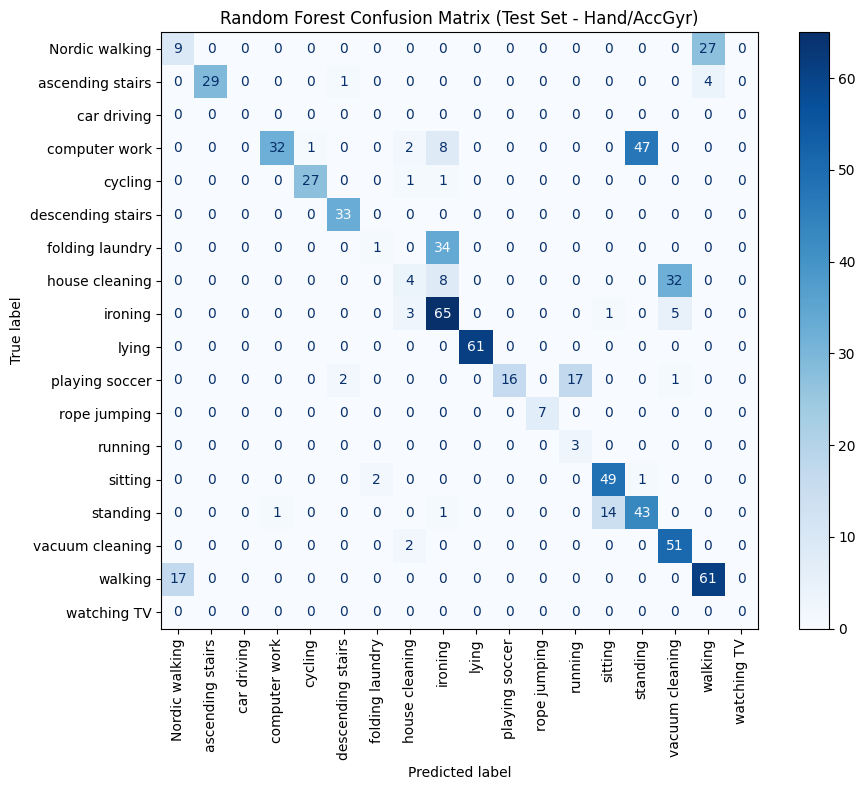

In [ ]:
# Classification Report and Confusion Matrix for Random Forest
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_rf.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('Random Forest Confusion Matrix (Test Set - Hand/AccGyr)')
plt.tight_layout()
plt.show()

                   precision    recall  f1-score   support

   Nordic walking       0.67      0.22      0.33        36
 ascending stairs       1.00      0.97      0.99        34
    computer work       0.48      0.29      0.36        90
          cycling       1.00      0.93      0.96        29
descending stairs       1.00      1.00      1.00        33
  folding laundry       0.50      0.11      0.19        35
   house cleaning       0.27      0.09      0.14        44
          ironing       0.61      0.95      0.74        74
            lying       0.76      1.00      0.87        61
   playing soccer       1.00      0.28      0.43        36
     rope jumping       1.00      1.00      1.00         7
          running       0.60      1.00      0.75         3
          sitting       0.56      0.44      0.49        52
         standing       0.43      0.68      0.52        59
  vacuum cleaning       0.59      0.96      0.73        53
          walking       0.72      0.95      0.82       

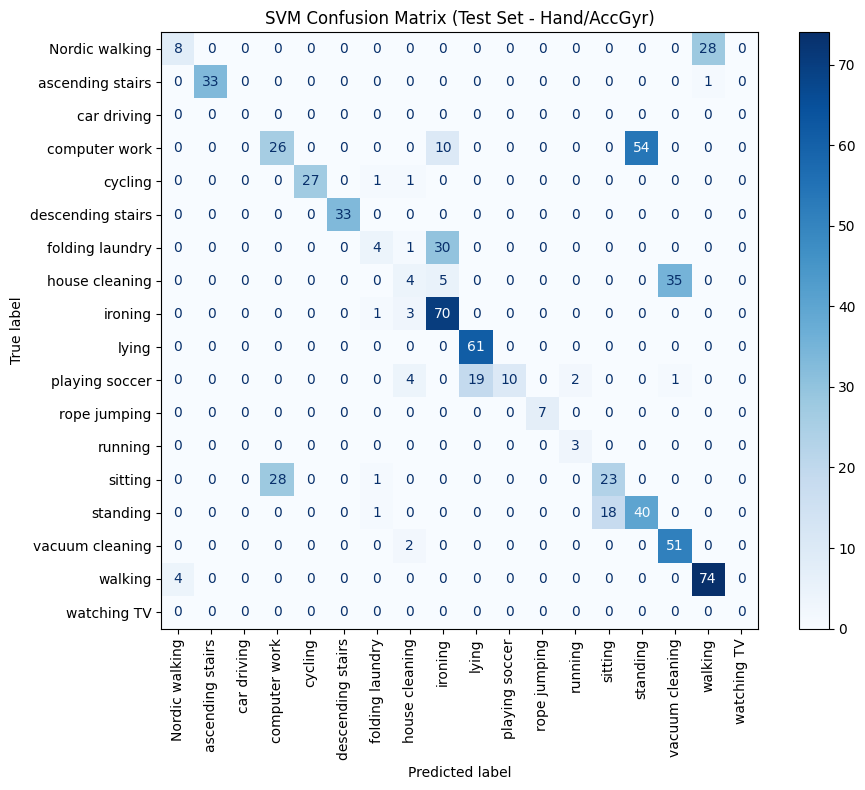

In [ ]:
# Classification Report and Confusion Matrix for SVM
print(classification_report(y_test, y_pred_svm, zero_division=0))

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_svm.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('SVM Confusion Matrix (Test Set - Hand/AccGyr)')
plt.tight_layout()
plt.show()

                   precision    recall  f1-score   support

   Nordic walking       0.77      0.47      0.59        36
 ascending stairs       0.94      0.97      0.96        34
      car driving       0.00      0.00      0.00         0
    computer work       0.76      0.41      0.53        90
          cycling       0.96      0.93      0.95        29
descending stairs       0.82      0.97      0.89        33
  folding laundry       0.45      0.14      0.22        35
   house cleaning       0.75      0.07      0.12        44
          ironing       0.62      0.99      0.76        74
            lying       1.00      1.00      1.00        61
   playing soccer       1.00      0.50      0.67        36
     rope jumping       0.00      0.00      0.00         7
          running       0.14      1.00      0.24         3
          sitting       0.61      0.71      0.65        52
         standing       0.38      0.51      0.43        59
  vacuum cleaning       0.63      0.98      0.77       

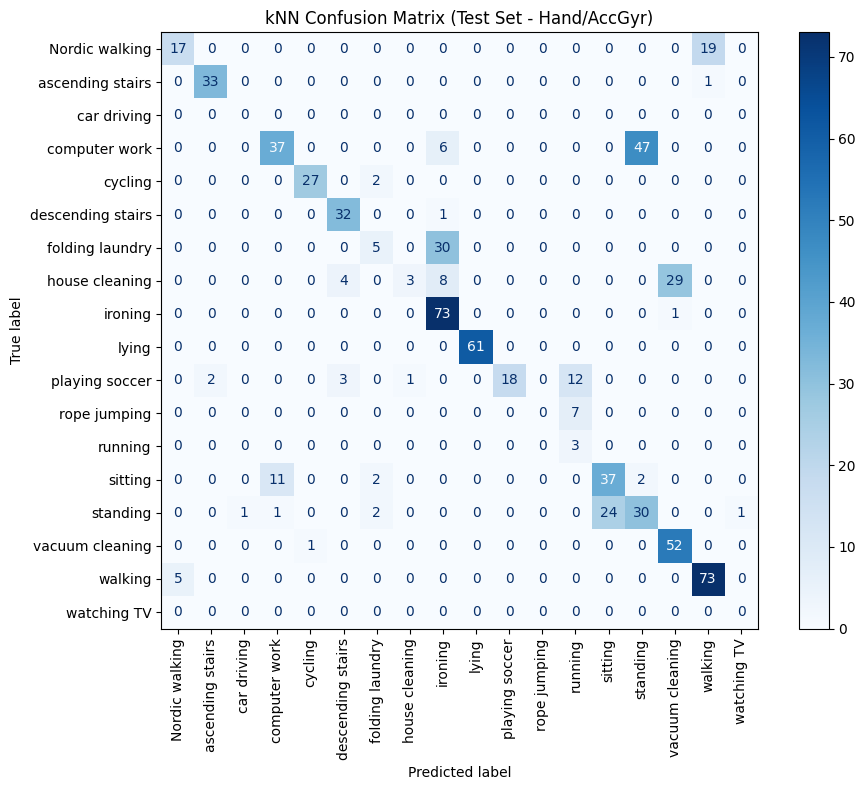

In [ ]:
# Classification Report and Confusion Matrix for kNN
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_knn.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('kNN Confusion Matrix (Test Set - Hand/AccGyr)')
plt.tight_layout()
plt.show()

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
# Random Forest Grid Search
rf_grid = GridSearchCV(
    estimator = RandomForestClassifier(n_jobs=-1),
    param_grid = config['fine_tune']['RandomForest']['param_grid'],
    cv = config['fine_tune']['cv'],
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = config['fine_tune']['verbose']
)
rf_grid.fit(X_train_scaled, y_train)

print("[RF] Best parameters:", rf_grid.best_params_)
print("[RF] Best CV f1_macro:", rf_grid.best_score_.round(4))

y_pred_rf_best = rf_grid.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf_best, zero_division=0))

cm_rf_best = confusion_matrix(y_test, y_pred_rf_best, labels=rf_grid.best_estimator_.classes_)
disp_rf_best = ConfusionMatrixDisplay(confusion_matrix=cm_rf_best, display_labels=rf_grid.best_estimator_.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_rf_best.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('Optimized Random Forest - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Fitting 5 folds for each of 64 candidates, totalling 320 fits
[SVM] Best parameters: {'C': 10, 'class_weight': None, 'gamma': 0.001, 'kernel': 'rbf'}
[SVM] Best CV accuracy: 0.7512
                   precision    recall  f1-score   support

   Nordic walking       1.00      1.00      1.00        36
 ascending stairs       1.00      0.88      0.94        34
      car driving       0.00      0.00      0.00         0
    computer work       0.82      0.93      0.87        90
          cycling       0.66      1.00      0.79        29
descending stairs       0.68      0.85      0.76        33
  folding laundry       0.50      0.14      0.22        35
   house cleaning       0.46      0.73      0.57        44
          ironing       0.64      0.66      0.65        74
            lying       0.88      0.75      0.81        61
   playing soccer       1.00      0.06      0.11        36
     rope jumping       0.00      0.00      0.00         7
          running       0.11      1.00      0.19   

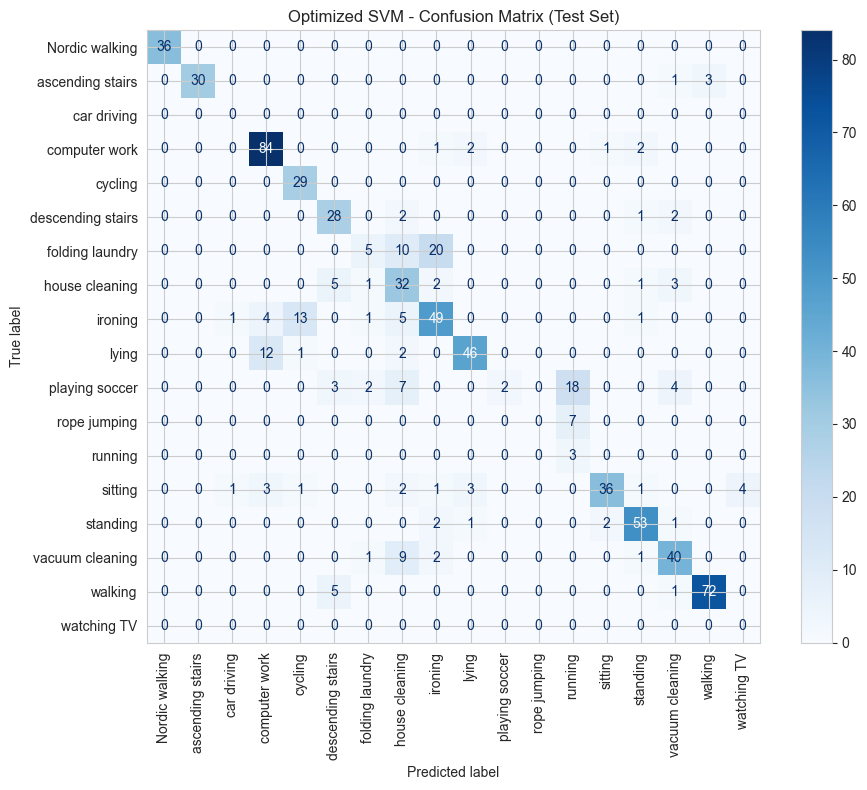

In [ ]:
# SVM Grid Search
svm_grid = GridSearchCV(
    estimator=SVC(),
    param_grid = config['fine_tune']['SVC']['param_grid'],
    cv = config['fine_tune']['cv'],
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = config['fine_tune']['verbose']
)
svm_grid.fit(X_train_scaled, y_train)

print("[SVM] Best parameters:", svm_grid.best_params_)
print("[SVM] Best CV f1_macro:", svm_grid.best_score_.round(4))

y_pred_svm_best = svm_grid.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm_best, zero_division=0))

cm_svm_best = confusion_matrix(y_test, y_pred_svm_best, labels=svm_grid.best_estimator_.classes_)
disp_svm_best = ConfusionMatrixDisplay(confusion_matrix=cm_svm_best, display_labels=svm_grid.best_estimator_.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_svm_best.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('Optimized SVM - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\konst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.67936286 0.68594814 0.68126263 0.68531621 0.68731874 0.69077281
 0.67945574 0.69010102 0.66940651 0.67450766        nan 0.75395573
        nan 0.74059647        nan 0.74231807        nan 0.7416713
        nan 0.73252575]
  warnings.warn(


[kNN] Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
[kNN] Best CV F1 macro: 0.754
                   precision    recall  f1-score   support

   Nordic walking       0.90      1.00      0.95        36
 ascending stairs       1.00      0.82      0.90        34
      car driving       0.00      0.00      0.00         0
    computer work       0.81      0.58      0.68        90
          cycling       0.67      1.00      0.81        29
descending stairs       0.88      0.85      0.86        33
  folding laundry       0.00      0.00      0.00        35
   house cleaning       0.40      0.43      0.42        44
          ironing       0.52      0.69      0.59        74
            lying       0.64      0.80      0.72        61
   playing soccer       1.00      0.22      0.36        36
     rope jumping       1.00      0.14      0.25         7
          running       0.15      1.00      0.26         3
          sitting       0.66      0.40      0.50       

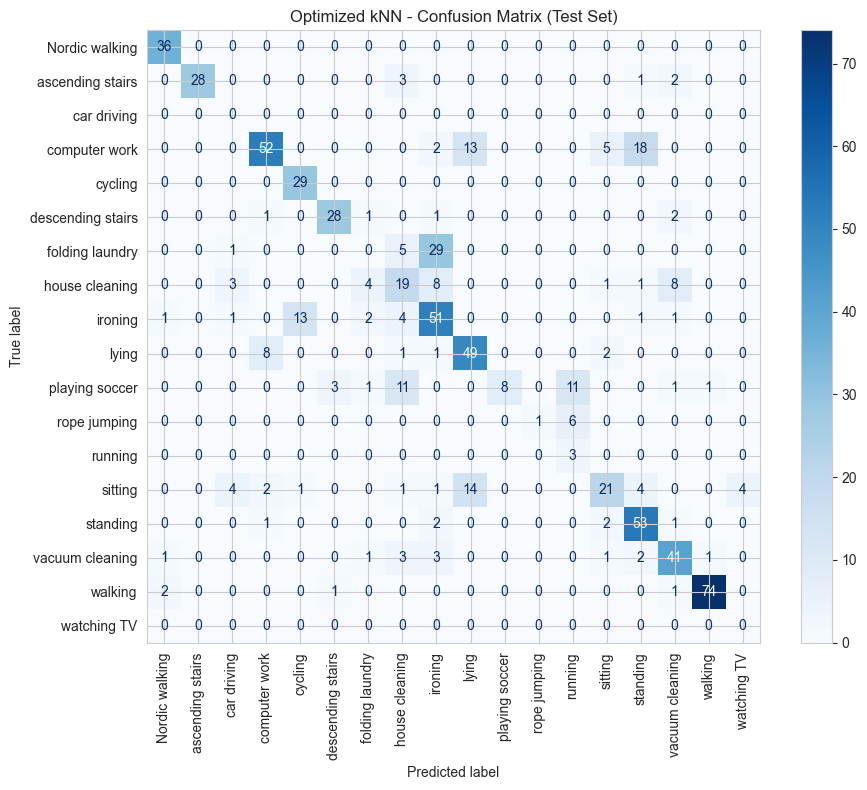

In [35]:
# kNN Grid Search
knn_grid = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = config['fine_tune']['kNN']['param_grid'],
    cv = config['fine_tune']['cv'],
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = config['fine_tune']['verbose']
)
knn_grid.fit(X_train_scaled, y_train)

print("[kNN] Best parameters:", knn_grid.best_params_)
print("[kNN] Best CV F1 macro:", knn_grid.best_score_.round(4))

y_pred_knn_best = knn_grid.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn_best, zero_division=0))

cm_knn_best = confusion_matrix(y_test, y_pred_knn_best, labels=knn_grid.best_estimator_.classes_)
disp_knn_best = ConfusionMatrixDisplay(confusion_matrix=cm_knn_best, display_labels=knn_grid.best_estimator_.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_knn_best.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('Optimized kNN - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

### Evaluate optimized classifier

Once you are satisfied with the wrist-only configuration, repeat the **load → process → train → evaluate** flow for the chest and ankle IMUs (and combinations thereof) and compare the metrics in your report.

In [10]:
# Fetching documents for more than one IMUs
IMU_LOCATIONS = ["hand", "ankle"]

query = {"imu_location": {"$in": IMU_LOCATIONS}, "sensor": "AccGyr"}
documents = list(coll.find(query))
print(f"Documents fetched: {len(documents)}")

Documents fetched: 216


In [11]:
# Every session key (subject, activity_id)  defines a simultaneous recording
# Each value is a dict: {"hand": doc, "chest": doc, ...}
sessions = defaultdict(dict)

for doc in documents:
    key = (doc["subject"], doc["activity_id"])
    sessions[key][doc["imu_location"]] = doc

print(f"Sessions: {len(sessions)}")

Sessions: 108


In [12]:
# Sliding window + alignment for multiple IMUs
# Each combined_window: dict {"hand": window_df, "chest": window_df, ...}
combined_windows = []
combined_metadata = []

for (subject, activity_id), imu_docs in sessions.items():
    activity_label = imu_docs[IMU_LOCATIONS[0]]["activity_label"]

    # Sliding window for each IMU independently
    imu_windows = {}
    for loc in IMU_LOCATIONS:
        segment_df = pd.DataFrame(imu_docs[loc]["data"])
        wins = sliding_window_pd(
            df=segment_df,
            ws=config["sliding_window"]["ws"],
            overlap=config["sliding_window"]["overlap"],
            w_type=config["sliding_window"]["w_type"],
            w_center=config["sliding_window"]["w_center"],
            print_stats=False,
        )
        imu_windows[loc] = wins

    # Alignment: keep only windows that exist in ALL IMUs
    n_windows = min(len(w) for w in imu_windows.values())

    for i in range(n_windows):
        combined_windows.append({loc: imu_windows[loc][i] for loc in IMU_LOCATIONS})
        combined_metadata.append({
            "subject": subject,
            "activity_label": activity_label,
        })

print(f"Total aligned windows: {len(combined_windows)}")

Total aligned windows: 3445


In [13]:
# Call filter_instances on each IMU's windows separately, since it works on list[DataFrame]
filtered_combined = []

# Separate lists of windows per location for filtering
per_loc_windows = {loc: [w[loc] for w in combined_windows] for loc in IMU_LOCATIONS}

per_loc_filtered = {
    loc: filter_instances(
        instances_list=wins,
        order=config["filter"]["order"],
        wn=config["filter"]["wn"],
        filter_type=config["filter"]["type"],
    )
    for loc, wins in per_loc_windows.items()
}

# Recombine the filtered windows into the original combined structure, but now with filtered data
for i in range(len(combined_windows)):
    filtered_combined.append({loc: per_loc_filtered[loc][i] for loc in IMU_LOCATIONS})

Number of filtered instances in the list: 3445
Number of filtered instances in the list: 3445


In [14]:
# Function to extract features from a window with prefix = imu_location
def extract_features_from_window(window_df, prefix):
    row = {}
    for col in window_df.columns:
        signal = window_df[col].values
        p = f"{prefix}_{col}"
        row[f"{p}_mean"] = np.mean(signal)
        row[f"{p}_std"] = np.std(signal)
        row[f"{p}_min"] = np.min(signal)
        row[f"{p}_max"] = np.max(signal)
        row[f"{p}_range"] = np.max(signal) - np.min(signal)
        row[f"{p}_median"] = np.median(signal)
        row[f"{p}_iqr"] = np.percentile(signal, 75) - np.percentile(signal, 25)
        row[f"{p}_rms"] = np.sqrt(np.mean(signal**2))
        row[f"{p}_energy"] = np.sum(signal**2) / len(signal)
        row[f"{p}_skew"] = pd.Series(signal).skew()
        row[f"{p}_kurt"] = pd.Series(signal).kurt()
        row[f"{p}_zc"] = np.sum(np.diff(np.sign(signal)) != 0)
        row[f"{p}_mad"] = np.mean(np.abs(signal - np.mean(signal)))
        row[f"{p}_sma"] = np.sum(np.abs(signal)) / len(signal)
        
        fft_vals = np.abs(np.fft.rfft(signal))
        freqs    = np.fft.rfftfreq(len(signal), d=1/100)
        row[f"{p}_fft_mean"]         = np.mean(fft_vals)
        row[f"{p}_fft_std"]          = np.std(fft_vals)
        row[f"{p}_fft_energy"]       = np.sum(fft_vals**2)
        row[f"{p}_dominant_freq"]    = freqs[np.argmax(fft_vals)]
        row[f"{p}_spectral_entropy"] = scipy.stats.entropy(fft_vals / np.sum(fft_vals))
    return row


# Extract features for each aligned & filtered window, prefixing feature names with the IMU location
feature_list = []

for window_dict in filtered_combined:
    row = {}
    for loc in IMU_LOCATIONS:
        row.update(extract_features_from_window(window_dict[loc], prefix=loc))
    feature_list.append(row)

X = pd.DataFrame(feature_list)
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (3445, 228)


In [15]:
# Pearson Correlation Filtering

# # Pearson Correlation Matrix Calculation for all feature pairs
corr_matrix = X.corr(method='pearson').abs()

# Keeping only the upper triangle(without the diagonal) to ensure each pair is evaluated once
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Determining which features to drop based on the correlation threshold of 0.9
# For each pair (A, B) with corr > 0.9, we drop B (the right member)
cols_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]

print(f"Initial features number: {X.shape[1]}")
print(f"Features to be dropped (|corr| > 0.9): {len(cols_to_drop)}")
print(f"Features remaining: {X.shape[1] - len(cols_to_drop)}")

# Filtering the features by dropping the identified ones
X = X.drop(columns=cols_to_drop)

print(f"\nFinal shape of X: {X.shape}")

Initial features number: 228
Features to be dropped (|corr| > 0.9): 118
Features remaining: 110

Final shape of X: (3445, 110)


In [17]:
TRAIN_SUBJECTS = ["101", "102", "104", "105", "106", "108"]
TEST_SUBJECTS  = ["103", "107", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

# Splitting the features into training and testing sets based on the subject IDs
meta_df = pd.DataFrame(combined_metadata)

train_mask = meta_df['subject'].isin(TRAIN_SUBJECTS)
test_mask  = meta_df['subject'].isin(TEST_SUBJECTS)

X_train = X[train_mask].values
X_test  = X[test_mask].values
y_train = meta_df[train_mask]['activity_label'].values
y_test  = meta_df[test_mask]['activity_label'].values

In [18]:
# Standardization of the features using Standard Scaler
scaler = StandardScaler()

# Fit the preprocessor on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Training Random Forest
rf = RandomForestClassifier(n_estimators = config['classifier']['RandomForest']['n_estimators'], 
                            class_weight = config['classifier']['RandomForest']['class_weight'], 
                            n_jobs = config['classifier']['RandomForest']['n_jobs'])
rf.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_rf = rf.predict(X_test_scaled)


# Training SVC
svm = SVC(kernel = config['classifier']['SVC']['kernel'], 
          C = config['classifier']['SVC']['C'], 
          gamma = config['classifier']['SVC']['gamma'])
svm.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_svm = svm.predict(X_test_scaled)


# Training kNN
knn = KNeighborsClassifier(n_neighbors = config['classifier']['kNN']['n_neighbors'],
                           weights = config['classifier']['kNN']['weights'],
                           metric = config['classifier']['kNN']['metric'],
                           n_jobs = config['classifier']['kNN']['n_jobs'])
knn.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_knn = knn.predict(X_test_scaled)

                   precision    recall  f1-score   support

   Nordic walking       1.00      1.00      1.00        36
 ascending stairs       1.00      1.00      1.00        34
      car driving       0.00      0.00      0.00         0
    computer work       0.85      0.91      0.88        90
          cycling       1.00      0.97      0.98        29
descending stairs       0.97      1.00      0.99        33
  folding laundry       0.00      0.00      0.00        35
   house cleaning       0.83      0.89      0.86        44
          ironing       0.59      0.89      0.71        74
            lying       0.98      1.00      0.99        61
   playing soccer       1.00      0.47      0.64        36
     rope jumping       0.88      1.00      0.93         7
          running       0.16      1.00      0.27         3
          sitting       0.92      0.69      0.79        52
         standing       0.84      0.90      0.87        59
  vacuum cleaning       0.96      0.81      0.88       

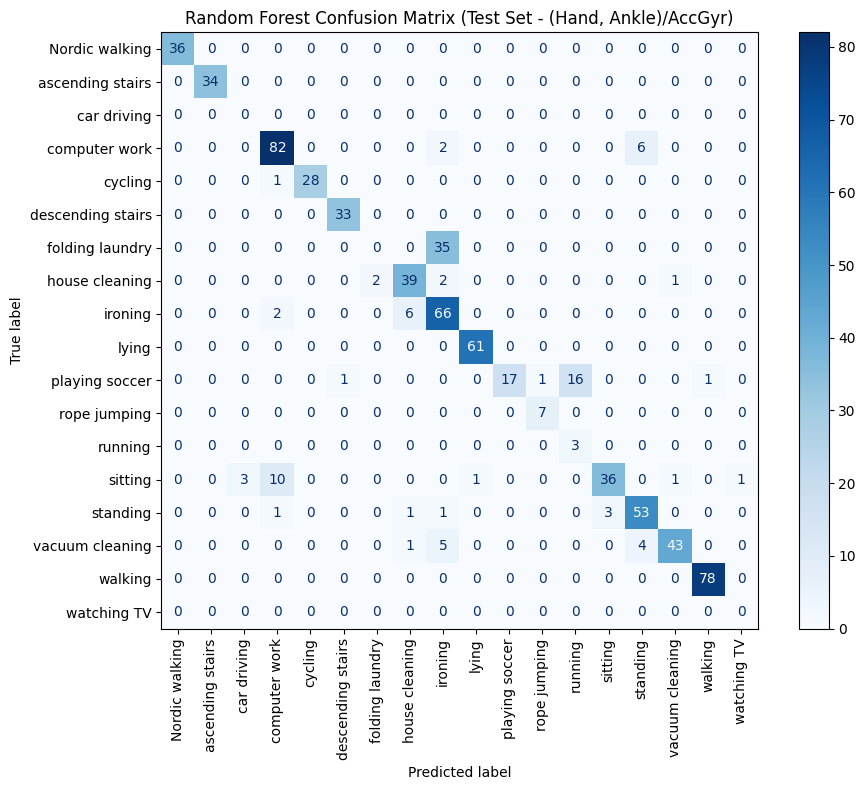

                   precision    recall  f1-score   support

   Nordic walking       1.00      0.83      0.91        36
 ascending stairs       1.00      1.00      1.00        34
    computer work       0.63      0.71      0.67        90
          cycling       1.00      0.93      0.96        29
descending stairs       0.88      0.85      0.86        33
  folding laundry       0.71      0.14      0.24        35
   house cleaning       0.67      0.80      0.73        44
          ironing       0.58      0.74      0.65        74
            lying       1.00      0.97      0.98        61
   playing soccer       1.00      0.50      0.67        36
     rope jumping       1.00      0.43      0.60         7
          running       0.27      1.00      0.43         3
          sitting       0.52      0.69      0.60        52
         standing       0.93      0.93      0.93        59
  vacuum cleaning       0.90      0.72      0.80        53
          walking       0.97      1.00      0.99       

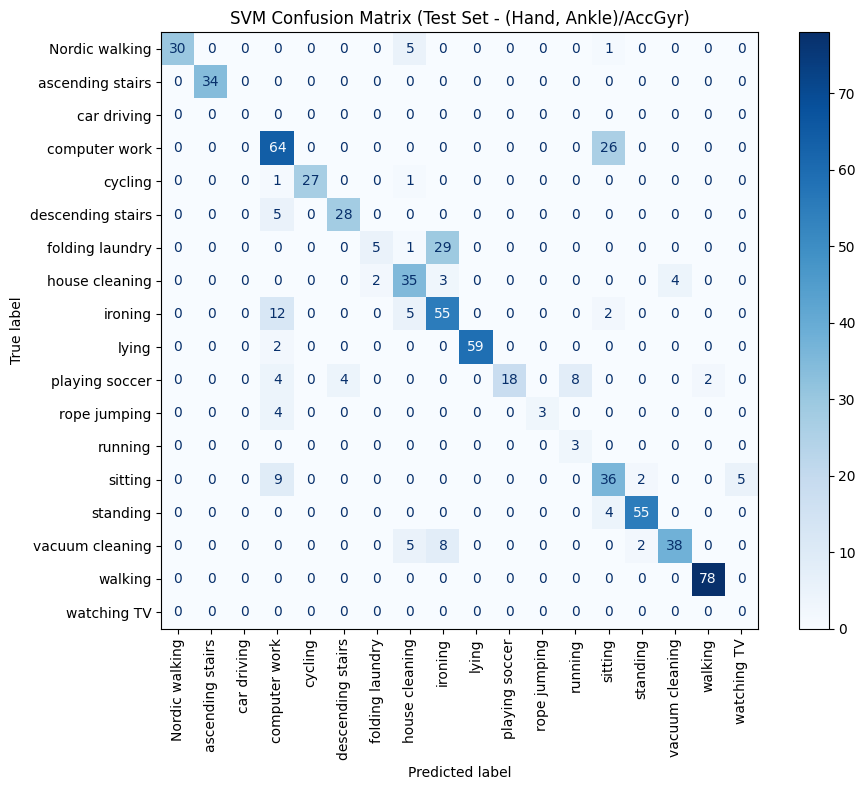

                   precision    recall  f1-score   support

   Nordic walking       0.97      1.00      0.99        36
 ascending stairs       1.00      1.00      1.00        34
    computer work       0.82      0.78      0.80        90
          cycling       0.94      1.00      0.97        29
descending stairs       1.00      0.97      0.98        33
  folding laundry       0.50      0.20      0.29        35
   house cleaning       0.80      0.36      0.50        44
          ironing       0.52      0.89      0.65        74
            lying       0.95      0.98      0.97        61
   playing soccer       1.00      0.75      0.86        36
     rope jumping       1.00      1.00      1.00         7
          running       0.30      1.00      0.46         3
          sitting       0.80      0.54      0.64        52
         standing       0.78      0.86      0.82        59
  vacuum cleaning       0.77      0.77      0.77        53
          walking       0.97      0.99      0.98       

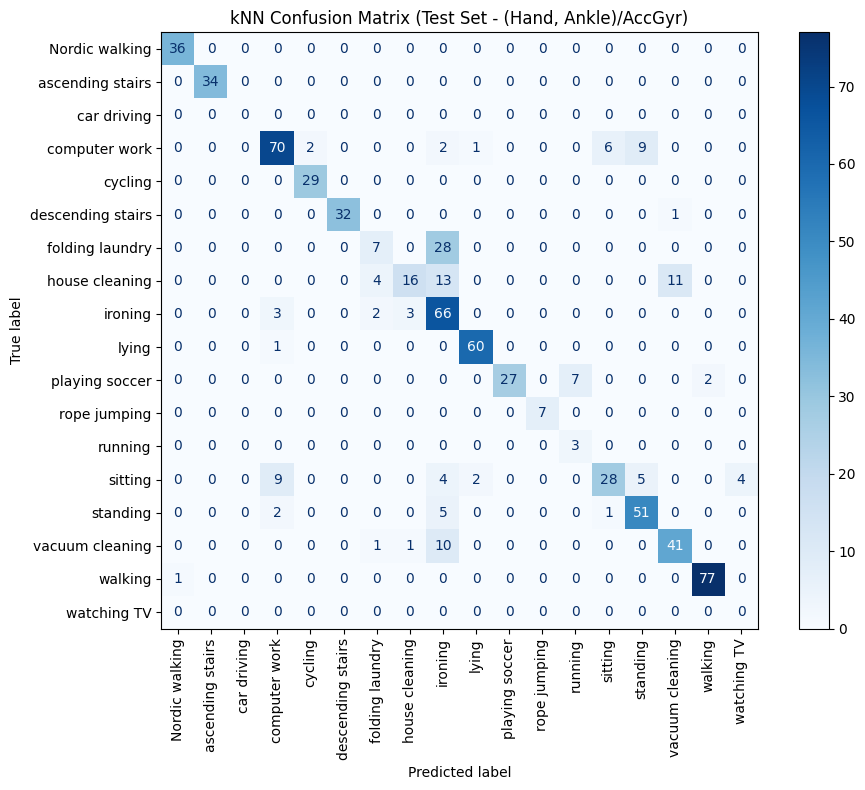

In [24]:
imu_locations_str = ", ".join(loc.capitalize() for loc in IMU_LOCATIONS)

# Classification Report and Confusion Matrix for Random Forest
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_rf.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title(f'Random Forest Confusion Matrix (Test Set - ({imu_locations_str})/AccGyr)')
plt.tight_layout()
plt.show()


# Classification Report and Confusion Matrix for SVM
print(classification_report(y_test, y_pred_svm, zero_division=0))

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_svm.plot(ax=ax, xticks_rotation=90, cmap='Blues')

plt.title(f'SVM Confusion Matrix (Test Set - ({imu_locations_str})/AccGyr)')
plt.tight_layout()
plt.show()


# Classification Report and Confusion Matrix for kNN
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_knn.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title(f'kNN Confusion Matrix (Test Set - ({imu_locations_str})/AccGyr)')
plt.tight_layout()
plt.show()